## Softmax Regression

* Picks **one answer out of many possible choices**
* Classifying something into **one of many categories** (*also called multinomial logistic regression*)

> For each possible category, the model gives a **score**, then softmax turns those scores into **probabilities** that add up to 1, and the category with the highest probability wins

---

## The Softmax Function
#### The Formula

For each score $z_i$ we compute:
$$softmax(z_i) = \frac{e^{z_i}}{\sum_{j = 1}^{k} e^{z_j}}$$

* $z_i$ = the raw score (logit) for category i
* $k$ = the number of classes
* For each category $k$, the score is:
      $$ z_k = w_k.x + b_k$$

#### The Loss Function
$$L = \frac {-1}{m} \sum_{i = 1}^{m} \sum_{k = 1}^{k} y_{k}^{i}log(\hat {y_{k}^{i}})$$

### Apply Softmax Regression on Iris Dataset From Scracth

In [101]:
# Import Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [102]:
# Load the dataset
iris = load_iris()

X = iris.data
y = iris.target

In [103]:
X.shape, y.shape

((150, 4), (150,))

In [104]:
# Show the classes
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [105]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [106]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [107]:
print("First flower:  ", X[0], "-> class", y[0])

First flower:   [5.1 3.5 1.4 0.2] -> class 0


In [108]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state = 42, stratify = y)

# Shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [109]:
# Standardize features (numerical)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [110]:
# One-hot-encode the labels
encoder = OneHotEncoder(sparse_output = False)
Y_train = encoder.fit_transform(y_train.reshape(-1, 1))
Y_test = encoder.transform(y_test.reshape(-1, 1))

In [111]:
Y_train.shape

(120, 3)

# Softmax Regression FROM SCRATCH

1. **Softmax Function** - turn scores into probabilities
2. **Forward pass** - compute predictions
3. **Loss** - measure error
4. **Gradient** - figure out how to improve
5. **Training loop** - repeat!

#### 1. The Softmax Function

In [112]:
def softmax(z):
    z_shifted = z - np.max(z, axis = 1, keepdims = True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis = 1, keepdims = True)

>IMPORTANT  
>Subtracting the max prevents overflow without changing the math  
>`keepdims = True` &rarr; keep the shape as `(N, 1)` so broadcasting works

#### 2. The Model's Parameters

We need:
* A **weight matrix** `w` of shape `(num_features, num_classes) = (4,3)`
* A **bias vector** `b` of shape `(num_classes,) = (3,)`

In [113]:
n_features = X_train.shape[1]
n_classes = Y_train.shape[1]

W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros(n_classes)

#### 2.1 Forward Pass

In [114]:
def forward(X, W, b):
    z = X @ W + b
    return softmax(z)

>IMPORTANT  
>`@` is matrix multiplication    
>Each row of the result is a probability distribution over the 3 classes

#### 3. Cross-entropy Loss

* Compare predicted probabilites to true one-hot labels

In [115]:
def cross_entropy(probs, Y_true):
    N = probs.shape[0]
    corrected_log_probs = np.log(probs[np.arange(N), Y_true.argmax(axis = 1)] + 1e-9)

    return np.mean(corrected_log_probs)

* `y_true.argmax(axis = 1)` &rarr; convets [0,1,0] back to 1
* `probs[np.arange(N), idx]` &rarr; numpy's fancy way of picking one element per row
* `+ 1e-9` &rarr; prevents `log(0)` which is `-infinity`
* `np.mean` &rarr; averages loss overall examples

#### 4. Gradients 
$$\frac{dL}{dz} = probs - y_{true}$$

In [116]:
def compute_gradients(X, probs, Y_true):
    N = X.shape[0]
    dz = (probs - Y_true) / N
    dw = X.T @ dz
    db = np.sum(dz, axis = 0)

    return dw, db

#### 5. Full Training Loop

In [117]:
def train(X, Y, epochs=500, lr=0.1):
    n_features = X.shape[1]
    n_classes  = Y.shape[1]

    W = np.random.randn(n_features, n_classes) * 0.01
    b = np.zeros(n_classes)

    losses = []

    for epoch in range(epochs):
        # Forward
        probs = forward(X, W, b)
        loss  = cross_entropy(probs, Y)
        losses.append(loss)

        # Backward
        dW, db = compute_gradients(X, probs, Y)

        # Update (gradient descent step)
        W -= lr * dW
        b -= lr * db

        if (epoch + 1) % 100 == 0:
            acc = np.mean(probs.argmax(axis=1) == Y.argmax(axis=1))
            print(f"Epoch {epoch+1:4d} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")

    return W, b, losses

In [118]:
W, b, losses = train(X_train, Y_train, epochs=500, lr=0.9)

Epoch  100 | Loss: -0.1231 | Train Acc: 0.9667
Epoch  200 | Loss: -0.0893 | Train Acc: 0.9750
Epoch  300 | Loss: -0.0760 | Train Acc: 0.9750
Epoch  400 | Loss: -0.0687 | Train Acc: 0.9750
Epoch  500 | Loss: -0.0640 | Train Acc: 0.9750


##### Evaluating on The Test Set

In [119]:
test_probs = forward(X_test, W, b)
test_preds = test_probs.argmax(axis=1)
test_acc   = np.mean(test_preds == y_test)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9667


#### Plot The Loss Curve

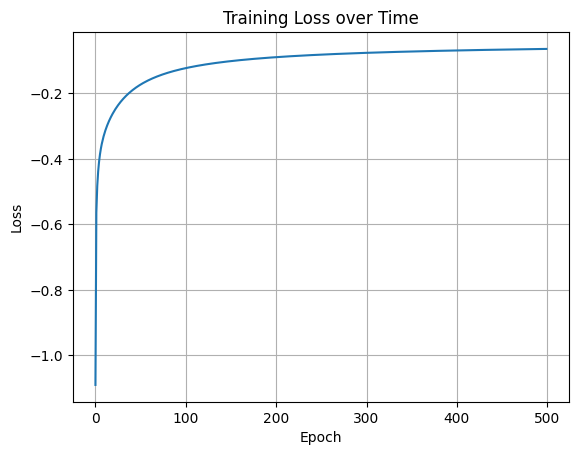

In [120]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.grid(True)
plt.show()

## Using Scikit-learn

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [124]:
logistic_reg = LogisticRegression(
    solver = 'lbfgs',
    max_iter = 200,
    random_state = 42
)
logistic_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in t

In [125]:
y_pred = logistic_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9333333333333333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [129]:
print("Weights shape:", logistic_reg.coef_.shape)      # (3, 4)
print("Bias shape:   ", logistic_reg.intercept_.shape) # (3,)
print("Weights:\n", logistic_reg.coef_)
print("Biases:\n", logistic_reg.intercept_)

Weights shape: (3, 4)
Bias shape:    (3,)
Weights:
 [[-1.08894494  1.02420763 -1.79905609 -1.68622819]
 [ 0.53633654 -0.36048698 -0.20407418 -0.80795703]
 [ 0.5526084  -0.66372065  2.00313027  2.49418523]]
Biases:
 [-0.30558672  1.90855554 -1.60296882]


#### Predict Probabilites on a New Flower

In [136]:
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])  # looks like a Setosa
new_flower_scaled = scaler.transform(new_flower)

probs = logistic_reg.predict_proba(new_flower_scaled)
pred  = logistic_reg.predict(new_flower_scaled)

print("Probabilities:", probs)
print("Predicted class:", iris.target_names[pred[0]])

Probabilities: [[9.80812738e-01 1.91869921e-02 2.69681097e-07]]
Predicted class: setosa


In [133]:
logistic_reg.predict_proba(new_flower_scaled)

array([[9.80812738e-01, 1.91869921e-02, 2.69681097e-07]])

In [134]:
logistic_reg.predict(new_flower_scaled)

array([0])

In [135]:
iris.target_names[pred]

array(['setosa'], dtype='<U10')